In [35]:
import torch
import torchvision
import os
from matplotlib import pyplot as plot
import time

batch_size = 64
epochs = 25
learning_rate = 0.001
dir = os.getcwd()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [36]:
train_dataset = torchvision.datasets.CIFAR10(
    root=dir, train=True, download=True,
    transform = torchvision.transforms.ToTensor()
)
test_dataset = torchvision.datasets.CIFAR10(
    root=dir, train=False, download=True,
    transform = torchvision.transforms.ToTensor()
)

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

Количество образцов для обучения: 50000


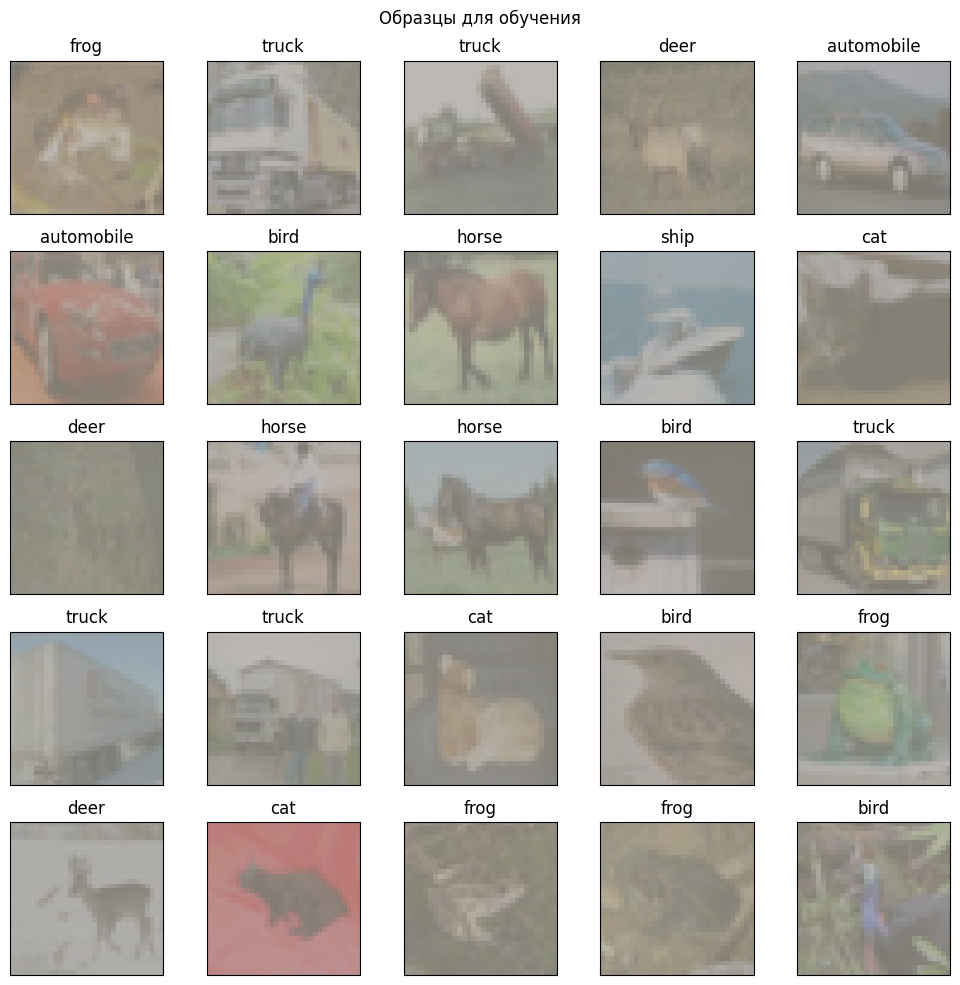

Количество образцов для проверки: 10000


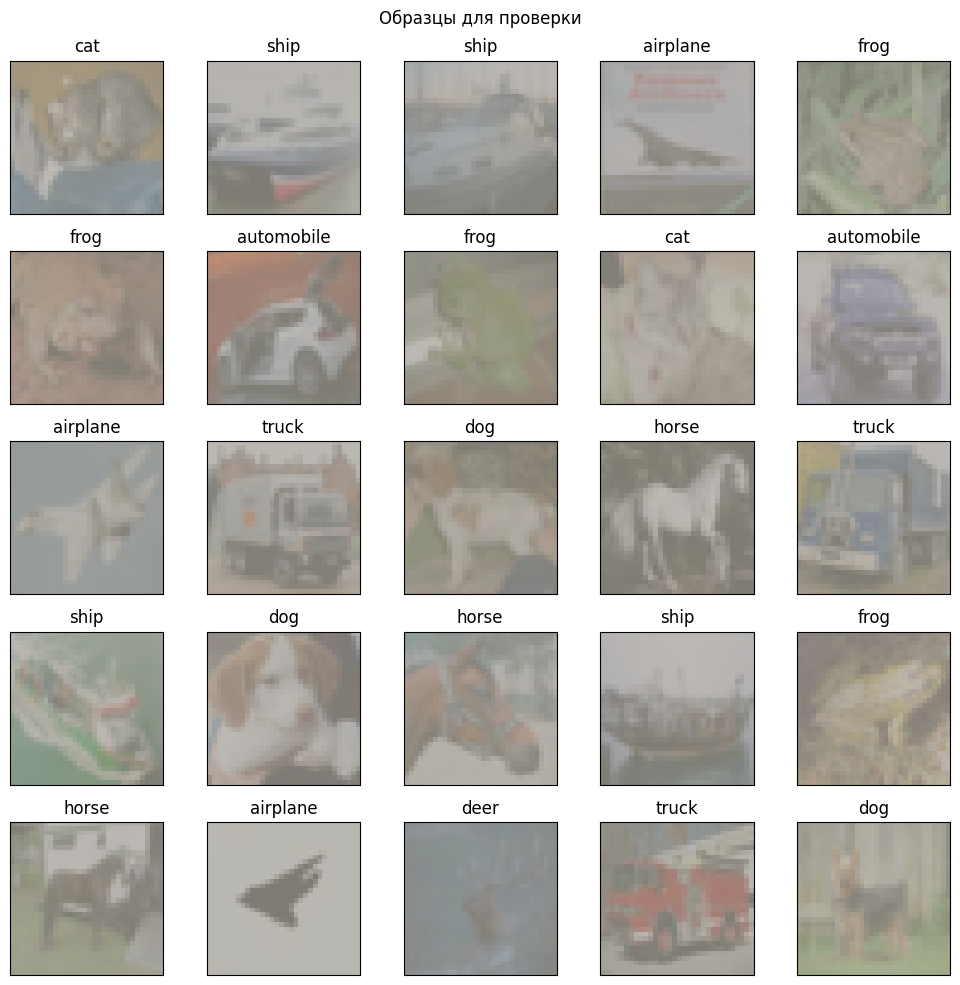

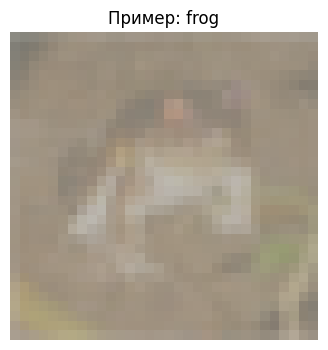

Обучающая выборка: 
(50000, 32, 32, 3)
Тестовая выборка: 
(10000, 32, 32, 3)


In [37]:
def get_norm_params(dataset):
    mean = dataset.data.mean(axis=(0, 1, 2))/255
    std = dataset.data.std(axis=(0, 1, 2))/255
    return torch.tensor(mean).reshape(3, 1, 1), torch.tensor(std).reshape(3, 1, 1)

def show_images(images, title, dataset_type='train'):
    images_for_x = 5
    images_for_y = 5

    figsize = (10, 10)
    fig, axes = plot.subplots(images_for_y, images_for_x, figsize=figsize)
    fig.suptitle(title)
    plot.setp(plot.gcf().get_axes(), xticks=[], yticks=[])
    if dataset_type == 'train':
        means, stds = get_norm_params(train_dataset)
    else:
        means, stds = get_norm_params(test_dataset)
    
    for i, ax in enumerate(axes.flat):
        if i >= len(images):
            break
        img = images[i][0]
        img = img * stds + means
        img = torch.clamp(img, 0, 1)
        img = img.numpy().transpose(1, 2, 0)
        ax.imshow(img)
        ax.set_title(class_names[images[i][1]])
    
    plot.tight_layout()
    plot.show()

def view_image(image, title):
    mean = train_dataset.data.mean(axis=(0,1,2))/255
    std = train_dataset.data.std(axis=(0,1,2))/255
    img_tensor = image[0]
    img_denormalized = img_tensor * torch.tensor(std).reshape(3, 1, 1) + torch.tensor(mean).reshape(3, 1, 1)
    img_denormalized = torch.clamp(img_denormalized, 0, 1)
    img = img_denormalized.numpy().transpose(1, 2, 0) 

    plot.figure(figsize=(4, 4))
    plot.title("{}: {}".format(title, class_names[image[1]]))
    plot.imshow(img)
    plot.axis('off')
    plot.show()

print('Количество образцов для обучения: {}'.format(len(train_dataset)))
show_images(train_dataset, 'Образцы для обучения', "train")

print('Количество образцов для проверки: {}'.format(len(test_dataset)))
show_images(test_dataset, 'Образцы для проверки', "test")

view_image(train_dataset[0], 'Пример')

print("Обучающая выборка: ")
print(train_dataset.data.shape)
print("Тестовая выборка: ")
print(test_dataset.data.shape)

In [38]:
means, stds = get_norm_params(train_dataset)
transform_train = torchvision.transforms.Compose(
    [
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize(means, stds)
    ]
)
means, stds = get_norm_params(test_dataset)
transform_test = torchvision.transforms.Compose(
    [
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize(means, stds)
    ]
)

train_dataset = torchvision.datasets.CIFAR10(
    root=dir, train=True, download=True,
    transform=transform_train
)
test_dataset = torchvision.datasets.CIFAR10(
    root=dir, train=False, download=True,
    transform=transform_test
)

train_data_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True
)
test_data_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=batch_size, shuffle=False
)

In [39]:
class MYResNet(torch.nn.Module):
  def __init__(self):
      super(MYResNet, self).__init__()
      self.conv1 = torch.nn.Sequential(
        torch.nn.Conv2d(3, 64, kernel_size=3, padding=1),
        torch.nn.BatchNorm2d(64),
        torch.nn.ReLU(inplace=True)
    )
      self.conv_and_pool_1 = torch.nn.Sequential(
        torch.nn.Sequential(
        torch.nn.Conv2d(64, 128, kernel_size=3, padding=1),
        torch.nn.BatchNorm2d(128),
        torch.nn.ReLU(inplace=True)
    ),
        torch.nn.MaxPool2d(kernel_size=2)
      )
      self.res1 = torch.nn.Sequential(
        torch.nn.Sequential(
        torch.nn.Conv2d(128, 128, kernel_size=3, padding=1),
        torch.nn.BatchNorm2d(128),
        torch.nn.ReLU(inplace=True)
    ),
        torch.nn.Sequential(
        torch.nn.Conv2d(128, 128, kernel_size=3, padding=1),
        torch.nn.BatchNorm2d(128),
        torch.nn.ReLU(inplace=True)
    )
      )
      self.conv_and_pool_2 = torch.nn.Sequential(
        torch.nn.Sequential(
        torch.nn.Conv2d(128, 256, kernel_size=3, padding=1),
        torch.nn.BatchNorm2d(256),
        torch.nn.ReLU(inplace=True)
    ),
          torch.nn.MaxPool2d(kernel_size=2)
      )
      self.conv_and_pool_3 = torch.nn.Sequential(
        torch.nn.Sequential(
        torch.nn.Conv2d(256, 512, kernel_size=3, padding=1),
        torch.nn.BatchNorm2d(512),
        torch.nn.ReLU(inplace=True)
    ),
          torch.nn.MaxPool2d(kernel_size=2)
      )
      self.res2 = torch.nn.Sequential(
        torch.nn.Sequential(
        torch.nn.Conv2d(512, 512, kernel_size=3, padding=1),
        torch.nn.BatchNorm2d(512),
        torch.nn.ReLU(inplace=True)
    ),
        torch.nn.Sequential(
        torch.nn.Conv2d(512, 512, kernel_size=3, padding=1),
        torch.nn.BatchNorm2d(512),
        torch.nn.ReLU(inplace=True)
    )
      )
      self.final_pool = torch.nn.MaxPool2d(kernel_size=4)
      self.dense = torch.nn.Sequential(
          torch.nn.Flatten(),
          torch.nn.Dropout(0.2),
          torch.nn.Linear(512, 10)
      )

  def forward(self, x):
    out = self.conv1(x)
    out = self.conv_and_pool_1(out)
    out = self.res1(out) + out
    out = self.conv_and_pool_2(out)
    out = self.conv_and_pool_3(out)
    out = self.res2(out) + out
    out = self.final_pool(out)
    out = self.dense(out)
    return out

In [32]:
Network = MYResNet()
Network

loss_function = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(Network.parameters(), lr=learning_rate)

In [ ]:
def get_accuracy(model, data_loader, device):
    tp = 0
    n = 0
    with torch.no_grad():
        for images, labels in data_loader:
            labels = labels.to(device)
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            n += labels.size(0)
            tp += (predicted == labels).sum()
            print(f"\rПодсчёт точности {n}", end="", flush=True)
    return tp / n

def get_loss(model, data_loader, device):
    loss = 0
    n = 0
    with torch.no_grad():
        for images, labels in data_loader:
            labels = labels.to(device)
            images = images.to(device)
            outputs = model(images)
            loss += loss_function(outputs, labels)
            n += labels.size(0)
            print(f"\rПодсчёт потерь {n}", end="", flush=True)
    return loss / n

print(f'Гиперпараметры: Критерий обучения = {learning_rate}, Размер батча = {batch_size}, Количество эпох = {epochs}')

Гиперпараметры: Критерий обучения = 0.001, Размер батча = 64, Количество эпох = 25


In [42]:
def train(Network):
    for epoch in range(epochs):
        start = time.time()
        losses = []
        for i, (images, labels) in enumerate(train_data_loader):
            images = images.to(device)
            labels = labels.to(device)

            outputs = Network(images)
            loss = loss_function(outputs, labels)
            losses.append(loss)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            print(f"\rБатч № {i+1}", end="", flush=True)

        duration = time.time() - start
        print(f'\rЭпоха {epoch + 1}               :\nПотери: {torch.stack(losses).mean():.4f}, Точность: {get_accuracy(Network,train_data_loader, device):.4f}, Время: {duration:.1f}с')
    print(f'\rПроверка точности: {get_accuracy(Network,test_data_loader, device):.4f}')
    print(f'\rПроверка потерь: {get_loss(Network,test_data_loader, device):.4f}')

train(Network)

Эпоха 1               :
Потери: 0.5511, Точность: 0.8616, Время: 542.8с
Эпоха 2               :
Потери: 0.4350, Точность: 0.8879, Время: 530.4с
Эпоха 3               :
Потери: 0.3403, Точность: 0.9180, Время: 530.7с
Эпоха 4               :
Потери: 0.2608, Точность: 0.9328, Время: 528.3с
Эпоха 5               :
Потери: 0.2086, Точность: 0.9548, Время: 529.2с
Эпоха 6               :
Потери: 0.1559, Точность: 0.9667, Время: 529.2с
Эпоха 7               :
Потери: 0.1263, Точность: 0.9645, Время: 529.7с
Эпоха 8               :
Потери: 0.0915, Точность: 0.9775, Время: 528.3с
Эпоха 9               :
Потери: 0.0852, Точность: 0.9771, Время: 529.2с
Эпоха 10               :
Потери: 0.0725, Точность: 0.9866, Время: 528.7с
Эпоха 11               :
Потери: 0.0664, Точность: 0.9838, Время: 527.7с
Эпоха 12               :
Потери: 0.0498, Точность: 0.9864, Время: 527.6с
Эпоха 13               :
Потери: 0.0548, Точность: 0.9847, Время: 530.4с
Эпоха 14               :
Потери: 0.0523, Точность: 0.9879, В